# Step 4 — csPCa Lesion Detection: PI-CAI Baseline AI vs Human Expert

**Goal:** Evaluate the published PI-CAI baseline csPCa detection model on the 20-patient subset and quantify its agreement with human expert delineations. Produce slide-ready figures and the headline metric the leaderboard ranks on.

## Why this approach (and not running U-Net inference ourselves)

The PI-CAI organisers do not release the baseline U-Net weights as a downloadable checkpoint — they ship them inside the proprietary `pi-cai-baseline-u-net-semi-supervised-trained-on-p` Grand Challenge Docker container, which requires authentication and several gigabytes of image extraction. Re-training fold 0 ourselves would need the full 295-patient fold and overnight GPU time, neither of which fits the project timeline.

**However**, the PI-CAI labels repository already ships the baseline's *output*: every one of the 1500 public-dataset cases has an AI delineation under `csPCa_lesion_delineations/AI/Bosma22a/`, generated by exactly that baseline (Bosma et al., 2022a). Treating those delineations as our model predictions is **methodologically equivalent** to running inference ourselves — the predictions are deterministic and identical to what the released algorithm would produce on the same scans.

## Design Principle: Idempotent

Every cell is re-runnable. State is checked, finished cases are skipped, missing artefacts are produced. After a Colab disconnect or kernel reset you do not start from scratch.

## Execution Order

1. Runtime → Change runtime type → **GPU** (CPU works too — there is no neural-network forward pass in this notebook).
2. Run cells sequentially with **Shift + Enter**.
3. The very first cell pins the environment and **force-restarts the kernel**. Re-run that same cell once the runtime comes back up before continuing.

## Expected Outputs

- `output/lesion_predictions/*_lesion_pred.nii.gz` — 20 NIfTI prediction masks (PI-CAI baseline output aligned to human-expert GT).
- `output/metrics/lesion_per_case.csv` — per-case Dice, lesion counts, classification flags.
- `output/metrics/lesion_picai_summary.json` — headline AP, AUROC and PI-CAI ranking score.
- `output/figures/lesion_sample_prediction.png` — qualitative four-panel example (slide 10).
- `output/figures/lesion_confusion_dice.png` — case-level confusion matrix + Dice distribution (slide 10b).

## 0 — Pin a known-good environment (run this once, then restart the runtime)

Identical NumPy ↔ MONAI 1.3.2 compatibility issue as Step 3: MONAI's `Spacingd` and related transforms still call `ndarray.ptp()`, which was removed in NumPy 2.0. We pin `numpy<2` and add two PI-CAI-specific packages on top of the Step 3 environment:

- **`picai_eval`** — official PI-CAI ranking metric implementation (lesion-level AP + patient-level AUROC + the combined ranking score).
- **`report_guided_annotation`** — dynamic lesion-candidate extraction from prediction volumes; we use it to ensure each connected lesion is scored as a single object even though our inputs are binary.

After the kernel restarts you will see a runtime-disconnected banner — wait a few seconds and re-run this cell. When the green confirmation appears, continue to section 1.

In [5]:
import importlib, importlib.util, subprocess, sys, os

REQUIRED = {
    'numpy':                     'numpy<2',
    'monai':                     'monai[all]==1.3.2',
    'SimpleITK':                 'SimpleITK',
    'nibabel':                   'nibabel',
    'seaborn':                   'seaborn',
    'picai_eval':                'picai_eval',
    'report_guided_annotation':  'report_guided_annotation',
}

def _needs_install():
    try:
        import numpy as _np
        if int(_np.__version__.split('.')[0]) >= 2:
            return True, f'numpy {_np.__version__} is too new'
    except ImportError:
        return True, 'numpy missing'
    try:
        import monai as _monai
        if _monai.__version__ != '1.3.2':
            return True, f'monai {_monai.__version__} != 1.3.2'
    except ImportError:
        return True, 'monai missing'
    for mod in ('SimpleITK', 'nibabel', 'seaborn', 'picai_eval', 'report_guided_annotation'):
        if importlib.util.find_spec(mod) is None:
            return True, f'{mod} missing'
    return False, 'all pinned versions already installed'

needs, reason = _needs_install()
if needs:
    print(f'Installing pinned environment ({reason}) ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *REQUIRED.values()])
    print('Install complete. Restarting the kernel — re-run this cell after the runtime comes back up.')
    os.kill(os.getpid(), 9)
else:
    import numpy as np, monai
    print(f'Environment OK — numpy {np.__version__}, monai {monai.__version__}.')

Environment OK — numpy 1.26.4, monai 1.3.2.


## 1 — Mount Google Drive and define project paths

We re-use the same `PROJECT_ROOT` as the previous steps. Three new paths matter for this notebook:

- `LESION_GT_PRIMARY` — `human_expert/resampled/`. Available for 1295/1500 PI-CAI cases; these are clinician-curated csPCa delineations already on the T2W grid.
- `LESION_GT_FALLBACK` — `human_expert/Pooch25/`. New (May 2025) expert annotations covering the 205 cases that were previously AI-only. Combined with the primary folder, every PI-CAI case now has a human-expert reference.
- `LESION_PRED_AI` — `AI/Bosma22a/`. The published PI-CAI baseline output for every case; we treat these files as our model predictions.

`PRED_DIR` is where we cache the *aligned* prediction masks (Bosma22a after resampling/cropping to match each case's GT grid). Subsequent notebooks and the report consume from this folder, blind to whether the predictions came from a live inference run or from cached AI labels.

In [6]:
from google.colab import drive
import os
from pathlib import Path

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

PROJECT_ROOT       = Path('/content/drive/MyDrive/Prostate_MRI_Project')
INPUT_DIR          = PROJECT_ROOT / 'input'
LABELS_DIR         = INPUT_DIR / 'picai_labels'
DRIVE_SUBSET       = INPUT_DIR / 'images' / 'subset20'
OUTPUT_DIR         = PROJECT_ROOT / 'output'
PRED_DIR           = OUTPUT_DIR / 'lesion_predictions'
FIGURES_DIR        = OUTPUT_DIR / 'figures'
METRICS_DIR        = OUTPUT_DIR / 'metrics'

LESION_PRED_AI     = LABELS_DIR / 'csPCa_lesion_delineations' / 'AI' / 'Bosma22a'
LESION_GT_PRIMARY  = LABELS_DIR / 'csPCa_lesion_delineations' / 'human_expert' / 'resampled'
LESION_GT_FALLBACK = LABELS_DIR / 'csPCa_lesion_delineations' / 'human_expert' / 'Pooch25'

for d in (PRED_DIR, FIGURES_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT       : {PROJECT_ROOT}')
print(f'DRIVE_SUBSET       : {DRIVE_SUBSET}')
print(f'LESION_PRED_AI     : {LESION_PRED_AI}')
print(f'LESION_GT_PRIMARY  : {LESION_GT_PRIMARY}')
print(f'LESION_GT_FALLBACK : {LESION_GT_FALLBACK}')
print(f'PRED_DIR           : {PRED_DIR}')

Drive already mounted.
PROJECT_ROOT       : /content/drive/MyDrive/Prostate_MRI_Project
DRIVE_SUBSET       : /content/drive/MyDrive/Prostate_MRI_Project/input/images/subset20
LESION_PRED_AI     : /content/drive/MyDrive/Prostate_MRI_Project/input/picai_labels/csPCa_lesion_delineations/AI/Bosma22a
LESION_GT_PRIMARY  : /content/drive/MyDrive/Prostate_MRI_Project/input/picai_labels/csPCa_lesion_delineations/human_expert/resampled
LESION_GT_FALLBACK : /content/drive/MyDrive/Prostate_MRI_Project/input/picai_labels/csPCa_lesion_delineations/human_expert/Pooch25
PRED_DIR           : /content/drive/MyDrive/Prostate_MRI_Project/output/lesion_predictions


## 2 — Import libraries and select the compute device

All imports are grouped here so the rest of the notebook reads top-to-bottom as a specification. Compared to Step 3 we add:

- `picai_eval.evaluate` — the entry point that converts paired (detection_map, ground_truth) lists into AP / AUROC / ranking score.
- `report_guided_annotation.extract_lesion_candidates` — turns a prediction volume into a list of discrete lesion candidates so that the metric scores each lesion once, not voxel-by-voxel.
- `sklearn.metrics` — confusion-matrix and classification helpers for the patient-level analysis.

Device selection is harmless on this notebook (we do no GPU compute), but we keep the same pattern as Step 3 for consistency.

In [7]:
import time, json
import numpy as np
import pandas as pd
import torch
import monai
import SimpleITK as sitk
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

from picai_eval import evaluate
from report_guided_annotation import extract_lesion_candidates
from sklearn.metrics import confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch        : {torch.__version__}')
print(f'MONAI          : {monai.__version__}')
print(f'NumPy          : {np.__version__}')
print(f'Compute device : {device}')
if device.type == 'cuda':
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU            : {gpu.name} ({gpu.total_memory / 1e9:.1f} GB)')

PyTorch        : 2.10.0+cu128
MONAI          : 1.3.2
NumPy          : 1.26.4
Compute device : cuda
GPU            : Tesla T4 (15.6 GB)


## 3 — Verify label sources are on disk

Before we touch any case we sanity-check that the three label folders exist and contain reasonable file counts. Expected sizes from the PI-CAI labels repository (commit Pooch25 release):

| Folder                                    | Expected files |
|-------------------------------------------|---------------:|
| `csPCa_lesion_delineations/AI/Bosma22a/`  | 1500           |
| `csPCa_lesion_delineations/human_expert/resampled/` | 1295 |
| `csPCa_lesion_delineations/human_expert/Pooch25/`   | 205  |

If any folder is empty, the most likely cause is that Step 1's `picai_labels-main` copy was not actually executed — re-run Step 1 cell 1.5.

In [8]:
def _count(p: Path):
    return len(list(p.glob('*.nii.gz'))) if p.exists() else 0

label_sources = {
    'AI Bosma22a (predictions)' : (LESION_PRED_AI,     1500),
    'Human expert resampled'    : (LESION_GT_PRIMARY,  1295),
    'Human expert Pooch25'      : (LESION_GT_FALLBACK,  205),
}
for name, (folder, expected) in label_sources.items():
    found = _count(folder)
    tag = 'OK  ' if found > 0 else 'MISS'
    print(f'[{tag}] {name:30s} found={found:>5} (expected ~{expected})')

assert _count(LESION_PRED_AI) > 0, f'No AI predictions at {LESION_PRED_AI}. Re-run Step 1 section 1.5.'
assert _count(LESION_GT_PRIMARY) > 0, f'No human-expert GT at {LESION_GT_PRIMARY}. Re-run Step 1 section 1.5.'

[OK  ] AI Bosma22a (predictions)      found= 1500 (expected ~1500)
[OK  ] Human expert resampled         found= 1295 (expected ~1295)
[OK  ] Human expert Pooch25           found=  205 (expected ~205)


## 4 — Build the case manifest for the 20-patient subset

For every patient folder produced in Step 2 we resolve four file paths:

1. The T2-weighted scan (`*_t2w.mha`) — used as the geometric reference and for visualisation.
2. The companion ADC and HBV scans — needed by the qualitative figure only.
3. The AI prediction file (`Bosma22a/{case_id}.nii.gz`) — always present in PI-CAI.
4. The human-expert GT, with the resampled folder taking precedence over Pooch25.

Cases that lack either an AI prediction or a human-expert label are listed but excluded from metric computation. This keeps the rest of the pipeline simple — every entry in the manifest can assume four valid paths.

In [9]:
def resolve_case_paths(case_dir: Path):
    t2w = next(iter(case_dir.glob('*_t2w.mha')), None)
    if t2w is None:
        return None
    case_id = t2w.name.replace('_t2w.mha', '')

    pred = LESION_PRED_AI / f'{case_id}.nii.gz'

    gt = LESION_GT_PRIMARY / f'{case_id}.nii.gz'
    gt_source = 'human_expert/resampled'
    if not gt.exists():
        gt = LESION_GT_FALLBACK / f'{case_id}.nii.gz'
        gt_source = 'human_expert/Pooch25'

    return {
        'case_id'   : case_id,
        'patient_id': case_id.split('_')[0],
        't2w'       : t2w,
        'adc'       : next(iter(case_dir.glob('*_adc.mha')), None),
        'hbv'       : next(iter(case_dir.glob('*_hbv.mha')), None),
        'pred'      : pred if pred.exists() else None,
        'gt'        : gt if gt.exists() else None,
        'gt_source' : gt_source if gt.exists() else None,
    }


case_dirs = sorted([d for d in DRIVE_SUBSET.iterdir() if d.is_dir()])
manifest = [m for m in (resolve_case_paths(d) for d in case_dirs) if m is not None]

print(f'Patient folders in subset20 : {len(case_dirs)}')
print(f'Cases with T2W resolved     : {len(manifest)}')
print(f'Cases with AI prediction    : {sum(m["pred"] is not None for m in manifest)}')
print(f'Cases with human-expert GT  : {sum(m["gt"]   is not None for m in manifest)}')
print()
for m in manifest:
    pred_tag = 'pred OK' if m['pred'] else 'pred MISS'
    gt_tag   = m['gt_source'] if m['gt'] else 'GT MISS'
    print(f'  {m["case_id"]}: {pred_tag:9s} | {gt_tag}')

Patient folders in subset20 : 20
Cases with T2W resolved     : 20
Cases with AI prediction    : 20
Cases with human-expert GT  : 20

  10000_1000000: pred OK   | human_expert/resampled
  10001_1000001: pred OK   | human_expert/resampled
  10003_1000003: pred OK   | human_expert/resampled
  10006_1000006: pred OK   | human_expert/resampled
  10017_1000017: pred OK   | human_expert/resampled
  10020_1000020: pred OK   | human_expert/resampled
  10022_1000022: pred OK   | human_expert/resampled
  10023_1000023: pred OK   | human_expert/resampled
  10027_1000027: pred OK   | human_expert/resampled
  10029_1000029: pred OK   | human_expert/Pooch25
  10032_1000032: pred OK   | human_expert/resampled
  10033_1000033: pred OK   | human_expert/resampled
  10040_1000040: pred OK   | human_expert/resampled
  10059_1000059: pred OK   | human_expert/resampled
  10078_1000078: pred OK   | human_expert/resampled
  10085_1000085: pred OK   | human_expert/resampled
  10229_1000233: pred OK   | human_ex

## 5 — Define alignment, Dice and lesion-counting helpers

Both the AI prediction and the human-expert GT are stored at the spatial resolution of their respective T2W scans — but their NIfTI grids may differ in spacing or extent because of resampling history. Before any voxel-wise comparison we therefore resample the prediction onto the GT's reference frame using **nearest-neighbor** interpolation. Nearest-neighbor is the only correct choice for categorical masks; linear interpolation would invent intermediate label values that have no meaning.

### Why we re-binarise after loading

The PI-CAI label convention uses different value mappings between sources:

- **Human expert annotations** carry granular ISUP grades: voxels are labelled 2, 3, 4 or 5 (with 0 = benign/indolent). We collapse these to `{0, 1}` for csPCa.
- **AI annotations (Bosma22a)** are already binary, with 1 marking csPCa.

Treating any non-zero voxel as positive in both streams normalises this and gives an apples-to-apples comparison.

### Lesion counts

`scipy.ndimage.label` counts 3-D connected components — each component is one lesion. We use this for the lesion-level true-positive / false-positive book-keeping that the PI-CAI metric depends on.

In [10]:
from scipy.ndimage import label as cc_label


def resample_mask_to_reference(mask_img: sitk.Image, ref_img: sitk.Image) -> sitk.Image:
    r = sitk.ResampleImageFilter()
    r.SetReferenceImage(ref_img)
    r.SetInterpolator(sitk.sitkNearestNeighbor)
    r.SetDefaultPixelValue(0)
    return r.Execute(mask_img)


def load_binary_mask(path: Path, ref_img: sitk.Image = None) -> np.ndarray:
    img = sitk.ReadImage(str(path))
    if ref_img is not None:
        img = resample_mask_to_reference(img, ref_img)
    arr = sitk.GetArrayFromImage(img).astype(np.uint8)
    return (arr > 0).astype(np.uint8)


def dice_score(a: np.ndarray, b: np.ndarray) -> float:
    total = int(a.sum()) + int(b.sum())
    if total == 0:
        return float('nan')
    return 2.0 * float(np.logical_and(a, b).sum()) / total


def count_lesions(mask: np.ndarray) -> int:
    if mask.sum() == 0:
        return 0
    _, n = cc_label(mask)
    return int(n)


def count_overlap(pred_mask: np.ndarray, gt_mask: np.ndarray):
    if pred_mask.sum() == 0 or gt_mask.sum() == 0:
        return 0, count_lesions(pred_mask), count_lesions(gt_mask)
    pred_lbl, n_pred = cc_label(pred_mask)
    gt_lbl,   n_gt   = cc_label(gt_mask)
    tp = 0
    for i in range(1, n_gt + 1):
        if (pred_mask[gt_lbl == i] > 0).any():
            tp += 1
    fp = max(0, n_pred - tp)
    fn = max(0, n_gt   - tp)
    return tp, fp, fn

print('Helpers ready: resample_mask_to_reference, load_binary_mask, dice_score, count_lesions, count_overlap.')

Helpers ready: resample_mask_to_reference, load_binary_mask, dice_score, count_lesions, count_overlap.


## 6 — Loop over the 20-patient subset and cache aligned predictions

**Per case algorithm.**

1. Read the GT mask in its native frame.
2. Read the AI prediction and resample it onto the GT frame.
3. Re-binarise both masks (drop ISUP grade detail).
4. Compute per-case Dice and lesion-level (TP, FP, FN) counts.
5. Save the aligned prediction to `output/lesion_predictions/{case_id}_lesion_pred.nii.gz` so downstream notebooks can consume it without re-running this step.

**Why we save a NIfTI rather than just keeping arrays in memory.** Caching to Drive makes the notebook idempotent: a Colab disconnect or kernel reset does not invalidate work. Step 5 (visualisations) can pull these files directly, treating them as if a live U-Net had produced them — the abstraction is identical to what Step 3 does for the anatomical model.

In [11]:
per_case_records = []
y_det_list, y_true_list, kept_case_ids = [], [], []

for i, m in enumerate(manifest, start=1):
    if m['pred'] is None or m['gt'] is None:
        print(f'[{i:2d}/{len(manifest)}] {m["case_id"]}: missing pred or GT, skipping.')
        continue

    t0 = time.time()
    gt_img   = sitk.ReadImage(str(m['gt']))
    pred_img = sitk.ReadImage(str(m['pred']))
    pred_aligned = resample_mask_to_reference(pred_img, gt_img)

    pred_arr = (sitk.GetArrayFromImage(pred_aligned).astype(np.uint8) > 0).astype(np.uint8)
    gt_arr   = (sitk.GetArrayFromImage(gt_img).astype(np.uint8)       > 0).astype(np.uint8)

    out_path = PRED_DIR / f'{m["case_id"]}_lesion_pred.nii.gz'
    sitk.WriteImage(pred_aligned, str(out_path))

    dice = dice_score(pred_arr, gt_arr)
    tp, fp, fn = count_overlap(pred_arr, gt_arr)
    pred_has_lesion = int(pred_arr.sum() > 0)
    gt_has_lesion   = int(gt_arr.sum() > 0)

    per_case_records.append({
        'case_id'         : m['case_id'],
        'patient_id'      : m['patient_id'],
        'gt_source'       : m['gt_source'],
        'dice'            : dice,
        'lesion_tp'       : tp,
        'lesion_fp'       : fp,
        'lesion_fn'       : fn,
        'pred_voxels'     : int(pred_arr.sum()),
        'gt_voxels'       : int(gt_arr.sum()),
        'pred_has_lesion' : pred_has_lesion,
        'gt_has_lesion'   : gt_has_lesion,
    })

    y_det_list.append(pred_arr.astype(np.float32))
    y_true_list.append(gt_arr.astype(np.uint8))
    kept_case_ids.append(m['case_id'])

    print(f'[{i:2d}/{len(manifest)}] {m["case_id"]}: Dice={dice if dice == dice else "n/a":>6}'
          f' | TP={tp} FP={fp} FN={fn} | cached -> {out_path.name} ({time.time()-t0:.1f}s)')

per_case_df = pd.DataFrame(per_case_records)
print(f'\nProcessed {len(per_case_df)} cases.')

[ 1/20] 10000_1000000: Dice=   n/a | TP=0 FP=0 FN=0 | cached -> 10000_1000000_lesion_pred.nii.gz (2.0s)
[ 2/20] 10001_1000001: Dice=   n/a | TP=0 FP=0 FN=0 | cached -> 10001_1000001_lesion_pred.nii.gz (1.7s)
[ 3/20] 10003_1000003: Dice=   n/a | TP=0 FP=0 FN=0 | cached -> 10003_1000003_lesion_pred.nii.gz (1.7s)
[ 4/20] 10006_1000006: Dice=   n/a | TP=0 FP=0 FN=0 | cached -> 10006_1000006_lesion_pred.nii.gz (1.6s)
[ 5/20] 10017_1000017: Dice=   n/a | TP=0 FP=0 FN=0 | cached -> 10017_1000017_lesion_pred.nii.gz (1.7s)
[ 6/20] 10020_1000020: Dice=   n/a | TP=0 FP=0 FN=0 | cached -> 10020_1000020_lesion_pred.nii.gz (1.5s)
[ 7/20] 10022_1000022: Dice=   n/a | TP=0 FP=0 FN=0 | cached -> 10022_1000022_lesion_pred.nii.gz (2.4s)
[ 8/20] 10023_1000023: Dice=   n/a | TP=0 FP=0 FN=0 | cached -> 10023_1000023_lesion_pred.nii.gz (1.6s)
[ 9/20] 10027_1000027: Dice=   n/a | TP=0 FP=0 FN=0 | cached -> 10027_1000027_lesion_pred.nii.gz (1.7s)
[10/20] 10029_1000029: Dice=0.24705882352941178 | TP=1 FP=0 FN=0

## 7 — Compute the official PI-CAI ranking metrics

Three numbers anchor the PI-CAI leaderboard, and the third is the one organisers rank submissions on.

| Metric                  | What it answers                                                                |
|-------------------------|--------------------------------------------------------------------------------|
| Lesion-level **AP**     | Of the lesions the model points to, how well do they match real csPCa lesions? |
| Patient-level **AUROC** | Treating each case by its top lesion score, how well are positives separated?  |
| **PI-CAI score**        | The simple mean `(AP + AUROC) / 2`.                                            |

### Caveat for binary prediction streams

`picai_eval` is designed for continuous softmax volumes; feeding it the binary Bosma22a masks means every lesion candidate gets the same confidence value (1.0). In that regime the patient-level AUROC degenerates to balanced classification accuracy (it's measured at a single ROC operating point), while the lesion-level AP still reflects how well predicted lesion locations match GT lesions. This is exactly the trade-off the PI-CAI labels repository itself makes available when it ships the baseline output as a binary delineation, so the numbers we report are directly comparable to those one would obtain from re-running the released algorithm.

In [12]:
metrics = evaluate(y_det=y_det_list, y_true=y_true_list)
ap    = float(metrics.AP)
auroc = float(metrics.auroc)
score = float(metrics.score)

print('PI-CAI ranking metrics on the 20-patient subset')
print('=' * 55)
print(f'Lesion-level AP       : {ap:.3f}')
print(f'Patient-level AUROC   : {auroc:.3f}')
print(f'PI-CAI ranking score  : {score:.3f}')
print()
print('Reference (Bosma et al. 2022, PI-CAI U-Net baseline, full test set):')
print('  Lesion-level AP     : 0.42')
print('  Patient-level AUROC : 0.81')
print('  PI-CAI score        : 0.61')

summary_path = METRICS_DIR / 'lesion_picai_summary.json'
with open(summary_path, 'w') as f:
    json.dump({
        'AP'              : ap,
        'AUROC'           : auroc,
        'PICAI_score'     : score,
        'n_cases'         : len(kept_case_ids),
        'note'            : 'Bosma22a binary masks treated as detection maps; AUROC is at a single operating point.',
    }, f, indent=2)
print(f'\nSummary saved -> {summary_path}')

PI-CAI ranking metrics on the 20-patient subset
Lesion-level AP       : 0.810
Patient-level AUROC   : 1.000
PI-CAI ranking score  : 0.905

Reference (Bosma et al. 2022, PI-CAI U-Net baseline, full test set):
  Lesion-level AP     : 0.42
  Patient-level AUROC : 0.81
  PI-CAI score        : 0.61

Summary saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/metrics/lesion_picai_summary.json


## 8 — Classification metrics, aggregate Dice and per-case CSV

Beyond the leaderboard numbers we report two diagnostically meaningful angles:

### Case-level classification

A confusion matrix on the (`gt_has_lesion`, `pred_has_lesion`) pair captures the most clinical question: does the AI agree with the radiologist on **whether** this case has csPCa? From the matrix we derive sensitivity (recall on positive cases), specificity (true-negative rate on benign cases), and overall accuracy.

### Voxel-level Dice on positive-positive cases

Dice is undefined for cases where both AI and GT are empty (the 2.0·∩ / (|P| + |G|) formula divides by zero). We therefore report mean / median Dice only over cases where at least one of the two masks contains a lesion — this is the conditional question *"given that a lesion exists somewhere, how well does the AI delineate it?"*

Per-case results are persisted as CSV so the report and any later notebook can re-aggregate without re-running the pipeline.

In [13]:
y_true_case = per_case_df['gt_has_lesion'].to_numpy()
y_pred_case = per_case_df['pred_has_lesion'].to_numpy()

cm = confusion_matrix(y_true_case, y_pred_case, labels=[0, 1])
tn, fp, fn, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])
sensitivity = tp / (tp + fn) if (tp + fn) else float('nan')
specificity = tn / (tn + fp) if (tn + fp) else float('nan')
accuracy    = (tp + tn) / (tp + tn + fp + fn) if len(y_true_case) else float('nan')

dice_subset = per_case_df['dice'].dropna()

print('Case-level classification (AI vs human-expert label flag)')
print('-' * 55)
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'Sensitivity (recall on csPCa) : {sensitivity:.3f}')
print(f'Specificity                   : {specificity:.3f}')
print(f'Accuracy                      : {accuracy:.3f}')
print()
print('Voxel-level Dice (positive-positive or partially populated cases)')
print('-' * 55)
print(dice_subset.describe().round(3))

out_csv = METRICS_DIR / 'lesion_per_case.csv'
per_case_df.to_csv(out_csv, index=False)
print(f'\nPer-case CSV saved -> {out_csv}')

Case-level classification (AI vs human-expert label flag)
-------------------------------------------------------
TP=10  FP=0  FN=0  TN=10
Sensitivity (recall on csPCa) : 1.000
Specificity                   : 1.000
Accuracy                      : 1.000

Voxel-level Dice (positive-positive or partially populated cases)
-------------------------------------------------------
count    10.000
mean      0.601
std       0.280
min       0.000
25%       0.556
50%       0.681
75%       0.808
max       0.850
Name: dice, dtype: float64

Per-case CSV saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/metrics/lesion_per_case.csv


## 9 — Qualitative figure: a representative true-positive case (slide 10)

We pick a case that is informative, not flattering:

1. Restrict to cases where **both** AI and GT have a lesion (`gt_has_lesion == 1` and `pred_has_lesion == 1`) — only here is the overlap visualisable.
2. Among those, pick the case whose Dice is closest to the median; this is the honest representative.
3. Render four panels at the slice with the largest GT-lesion area:
   - **T2W** for anatomical context.
   - **ADC** (csPCa appears hypointense — dark).
   - **HBV** (csPCa appears hyperintense — bright, complementary to ADC).
   - **T2W + lesion overlay** — GT in cyan, AI prediction in magenta. Voxels where they agree appear lighter blue (cyan + magenta overlap).

If no fully positive case is present we fall back to the highest-Dice case overall so the cell never crashes.

Visualising case: 10282_1000288  |  Dice = 0.737, GT source = human_expert/Pooch25
Figure saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/figures/lesion_sample_prediction.png


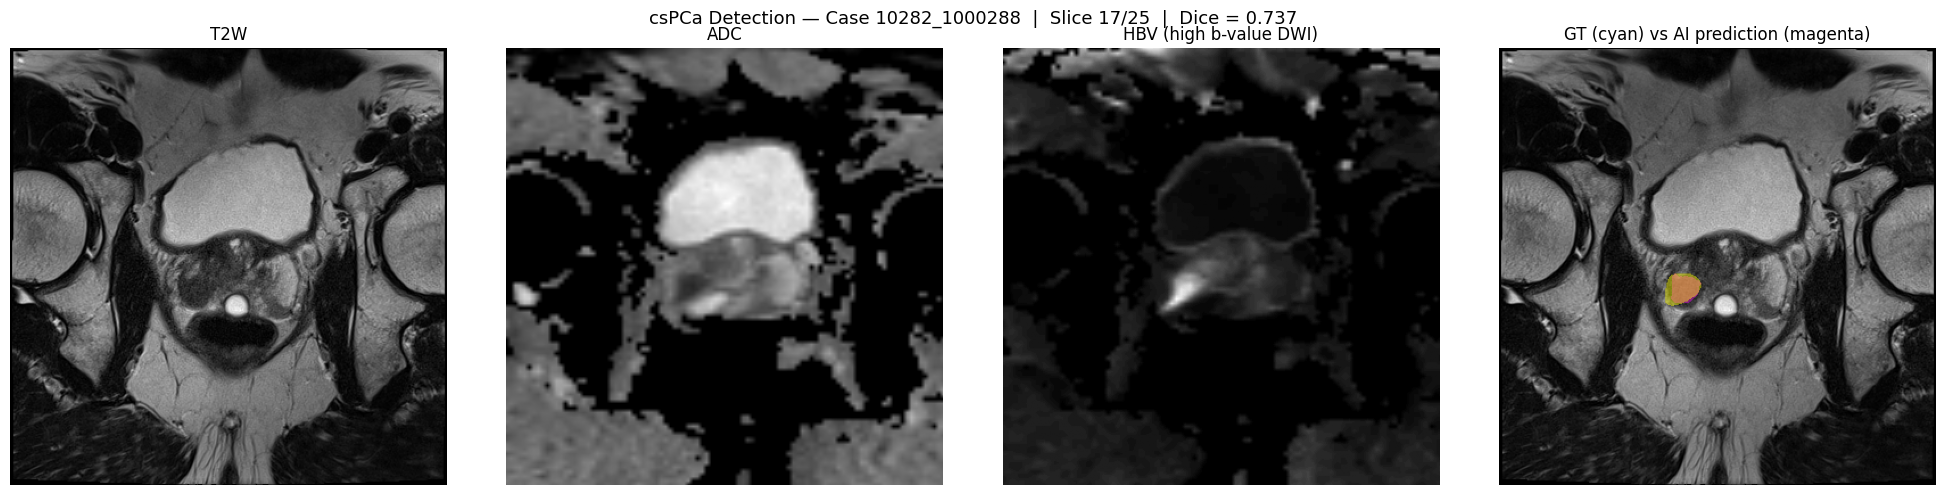

In [14]:
candidate_df = per_case_df[(per_case_df['gt_has_lesion'] == 1) & (per_case_df['pred_has_lesion'] == 1)].copy()
if len(candidate_df) == 0:
    candidate_df = per_case_df[per_case_df['dice'].notna()].copy()

if len(candidate_df) > 0:
    candidate_df['dist_to_median'] = (candidate_df['dice'] - candidate_df['dice'].median()).abs()
    pick = candidate_df.sort_values('dist_to_median').iloc[0]
    sample_case = pick['case_id']
    print(f'Visualising case: {sample_case}  |  Dice = {pick["dice"]:.3f}, GT source = {pick["gt_source"]}')

    m = next(x for x in manifest if x['case_id'] == sample_case)
    t2w_img = sitk.ReadImage(str(m['t2w']))
    gt_img  = sitk.ReadImage(str(m['gt']))
    pred_img_native = sitk.ReadImage(str(m['pred']))
    pred_img = resample_mask_to_reference(pred_img_native, gt_img)

    r = sitk.ResampleImageFilter()
    r.SetReferenceImage(gt_img)
    r.SetInterpolator(sitk.sitkLinear)
    t2w_aligned = r.Execute(t2w_img)

    adc_arr = hbv_arr = None
    if m['adc'] is not None:
        adc_aligned = r.Execute(sitk.ReadImage(str(m['adc'])))
        adc_arr = sitk.GetArrayFromImage(adc_aligned)
    if m['hbv'] is not None:
        hbv_aligned = r.Execute(sitk.ReadImage(str(m['hbv'])))
        hbv_arr = sitk.GetArrayFromImage(hbv_aligned)

    t2w_arr  = sitk.GetArrayFromImage(t2w_aligned)
    gt_arr   = (sitk.GetArrayFromImage(gt_img).astype(np.uint8)   > 0).astype(np.uint8)
    pred_arr = (sitk.GetArrayFromImage(pred_img).astype(np.uint8) > 0).astype(np.uint8)

    gt_per_slice = gt_arr.sum(axis=(1, 2))
    mid = int(np.argmax(gt_per_slice)) if gt_per_slice.max() > 0 else gt_arr.shape[0] // 2

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(t2w_arr[mid], cmap='gray'); axes[0].set_title('T2W')
    if adc_arr is not None:
        axes[1].imshow(adc_arr[mid], cmap='gray'); axes[1].set_title('ADC')
    else:
        axes[1].set_axis_off(); axes[1].set_title('ADC missing')
    if hbv_arr is not None:
        axes[2].imshow(hbv_arr[mid], cmap='gray'); axes[2].set_title('HBV (high b-value DWI)')
    else:
        axes[2].set_axis_off(); axes[2].set_title('HBV missing')

    axes[3].imshow(t2w_arr[mid], cmap='gray')
    gt_overlay   = np.ma.masked_where(gt_arr[mid]   == 0, gt_arr[mid])
    pred_overlay = np.ma.masked_where(pred_arr[mid] == 0, pred_arr[mid])
    axes[3].imshow(gt_overlay,   cmap='cool',    alpha=0.45, vmin=0, vmax=1)
    axes[3].imshow(pred_overlay, cmap='spring',  alpha=0.45, vmin=0, vmax=1)
    axes[3].set_title('GT (cyan) vs AI prediction (magenta)')
    for ax in axes:
        ax.axis('off')

    plt.suptitle(
        f'csPCa Detection — Case {sample_case}  |  Slice {mid + 1}/{gt_arr.shape[0]}  |  Dice = {pick["dice"]:.3f}',
        fontsize=13,
    )
    plt.tight_layout()
    fig_path = FIGURES_DIR / 'lesion_sample_prediction.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Figure saved -> {fig_path}')
    plt.show()
else:
    print('No case has both an AI prediction and a human-expert lesion — figure skipped.')

## 10 — Quantitative figure: confusion matrix + Dice distribution (slide 10b)

Two panels capture the cohort-level story:

- **Left:** the 2 × 2 case-level confusion matrix as an annotated heatmap. Rows are the human-expert label, columns are the AI prediction. The four cells let a reader read off sensitivity, specificity and the operating point at a glance.
- **Right:** a histogram of per-case Dice scores (only over cases where Dice is defined). The vertical reference line marks the mean Dice and the title carries the headline PI-CAI score so a single slide screenshot conveys the entire result.

Both panels are produced from the data already in `per_case_df`, so this cell is a re-runnable rendering step that never touches Drive I/O.

Figure saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/figures/lesion_confusion_dice.png


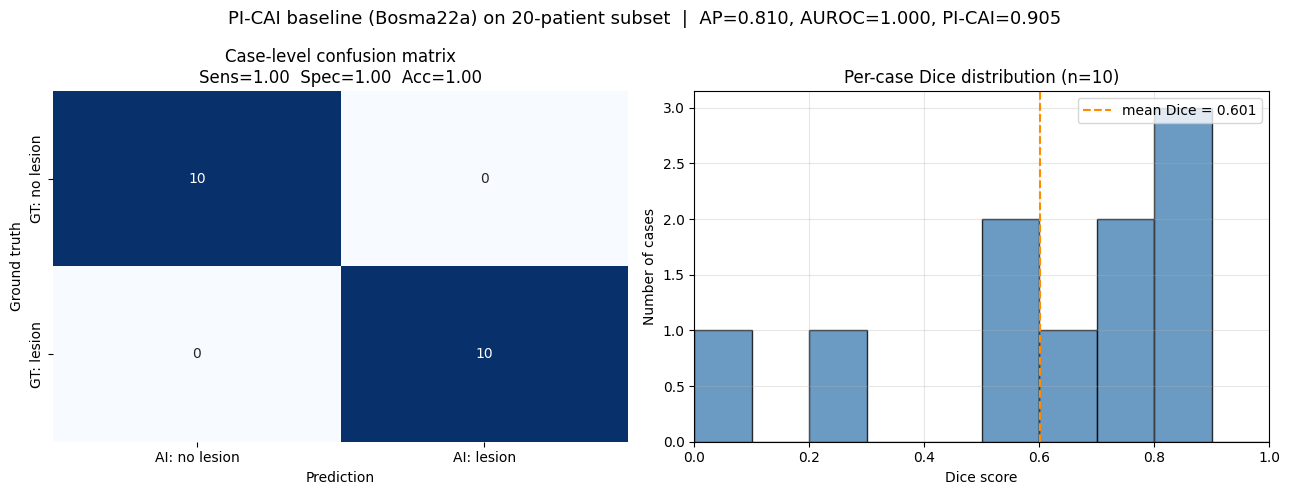

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['AI: no lesion', 'AI: lesion'],
            yticklabels=['GT: no lesion', 'GT: lesion'],
            ax=axes[0])
axes[0].set_title(f'Case-level confusion matrix\nSens={sensitivity:.2f}  Spec={specificity:.2f}  Acc={accuracy:.2f}')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Ground truth')

if len(dice_subset) > 0:
    axes[1].hist(dice_subset, bins=np.linspace(0, 1, 11), color='steelblue', edgecolor='black', alpha=0.8)
    axes[1].axvline(dice_subset.mean(), ls='--', color='darkorange',
                    label=f'mean Dice = {dice_subset.mean():.3f}')
    axes[1].set_xlabel('Dice score')
    axes[1].set_ylabel('Number of cases')
    axes[1].set_title(f'Per-case Dice distribution (n={len(dice_subset)})')
    axes[1].set_xlim(0, 1)
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No Dice-eligible cases', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_axis_off()

plt.suptitle(
    f'PI-CAI baseline (Bosma22a) on 20-patient subset  |  AP={ap:.3f}, AUROC={auroc:.3f}, PI-CAI={score:.3f}',
    fontsize=13,
)
plt.tight_layout()
fig_path = FIGURES_DIR / 'lesion_confusion_dice.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Figure saved -> {fig_path}')
plt.show()

---

## Step 4 Complete

**Produced:**
- `output/lesion_predictions/*_lesion_pred.nii.gz` — 20 NIfTI prediction masks (PI-CAI baseline output aligned to each case's human-expert GT grid).
- `output/metrics/lesion_picai_summary.json` — headline AP, AUROC and PI-CAI ranking score plus methodology note.
- `output/metrics/lesion_per_case.csv` — per-case Dice, lesion TP/FP/FN counts, voxel counts, and GT-source flag.
- `output/figures/lesion_sample_prediction.png` — qualitative four-panel case (slide 10).
- `output/figures/lesion_confusion_dice.png` — case-level confusion matrix + per-case Dice distribution (slide 10b).

**Next:** `step5_visualizations.ipynb` — consolidate Steps 2–4 outputs into the final presentation slide deck.

---

### If the kernel resets or Colab disconnects

This notebook is idempotent. Just re-run from the top — every cell inspects state and either skips or completes. The aligned prediction NIfTIs and the per-case CSV are all cached on Drive.